# HGHMNDS Clothing Market Analysis

## 1. Introduction

This notebook analyzes HGHMNDS Clothing's market presence across two Philippine
e-commerce platforms: **Shopee** and **Lazada**.

**Data sources:**
- Shopee Philippines — HGHMNDS Clothing storefront + third-party sellers using the brand name
- Lazada Philippines — same, scraped separately (different fields: Shopee tracks 30-day
  sales, Lazada tracks lifetime sales)

**Scrape date:** 2026-07-05

**Pipeline:** raw Excel (`data/raw/`) -> `scripts/01_clean.py` -> cleaned CSVs
(`data/cleaned/`) -> this notebook / `scripts/02_eda.py` for analysis.

## 2. Data Loading

In [1]:
%matplotlib inline
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = {"Shopee": "#ee4d2d", "Lazada": "#0f156d"}
STOPWORDS = {"the", "a", "is", "it", "and", "in", "of", "to", "i", "my", "for",
             "was", "so", "very", "this", "that", "are", "with", "on"}

CLEANED_DIR = Path("../data/cleaned")

combined = pd.read_csv(CLEANED_DIR / "combined_clean.csv")
shopee = pd.read_csv(CLEANED_DIR / "shopee_clean.csv")
lazada = pd.read_csv(CLEANED_DIR / "lazada_clean.csv")
shopee_reviews = pd.read_csv(CLEANED_DIR / "shopee_reviews_clean.csv")
lazada_reviews = pd.read_csv(CLEANED_DIR / "lazada_reviews_clean.csv")

for name, df in [("combined", combined), ("shopee", shopee), ("lazada", lazada),
                  ("shopee_reviews", shopee_reviews), ("lazada_reviews", lazada_reviews)]:
    print(f"{name:16s} {df.shape}")

combined         (221, 17)
shopee           (118, 29)
lazada           (103, 31)
shopee_reviews   (1431, 9)
lazada_reviews   (381, 9)


## 3. Pricing Analysis

In [2]:
price_stats = combined.groupby("platform")["price"].agg(
    mean="mean", median="median", min="min", max="max").round(2)
price_stats

,mean,median,min,max
platform,,,,
Lazada,576.63,500.0,100.0,2000.0
Shopee,566.09,620.0,119.0,1700.0


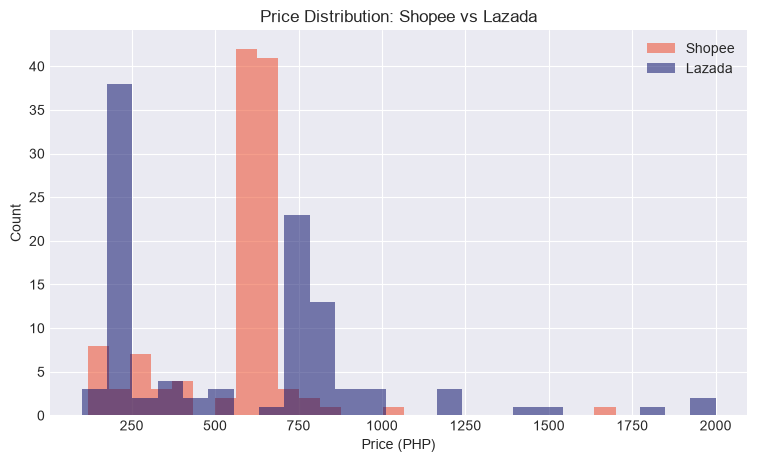

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for plat in ["Shopee", "Lazada"]:
    data = combined.loc[combined["platform"] == plat, "price"]
    ax.hist(data, bins=25, alpha=0.55, label=plat, color=PALETTE[plat])
ax.set_xlabel("Price (PHP)"); ax.set_ylabel("Count")
ax.set_title("Price Distribution: Shopee vs Lazada")
ax.legend()
plt.show()

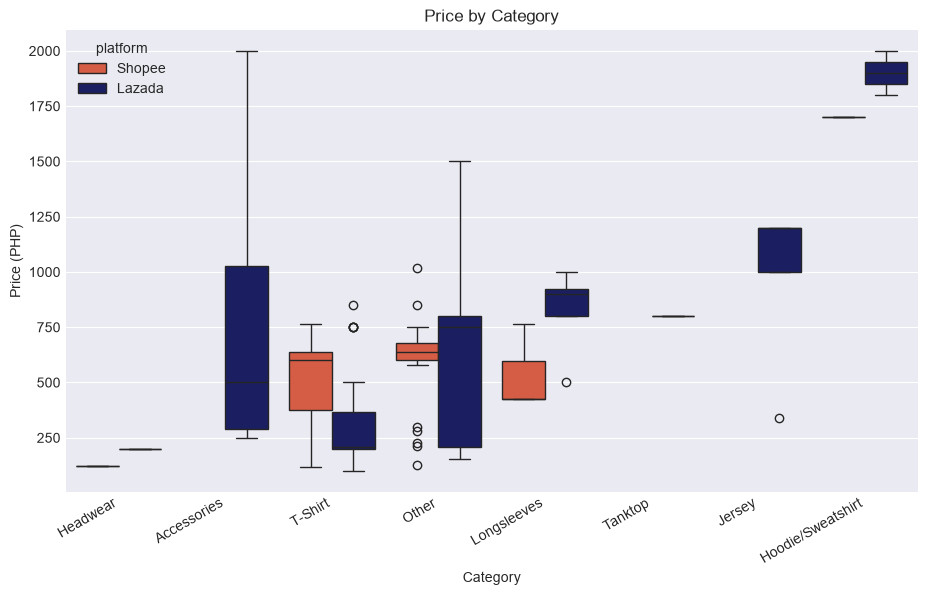

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
order = combined.groupby("category_derived")["price"].median().sort_values().index
sns.boxplot(data=combined, x="category_derived", y="price", hue="platform",
            order=order, palette=PALETTE, ax=ax)
ax.set_xlabel("Category"); ax.set_ylabel("Price (PHP)")
ax.set_title("Price by Category")
plt.xticks(rotation=30, ha="right")
plt.show()

In [5]:
# Average discount %, authentic + non-suspicious listings only.
# Null discount_pct means "no active promo" (0% off), so fill before averaging.
clean_mask = combined["is_authentic"] & ~combined["is_suspicious"]
avg_discount = (combined.loc[clean_mask].assign(discount_pct=lambda d: d["discount_pct"].fillna(0))
                .groupby("platform")["discount_pct"].mean().round(2))
avg_discount

platform
Lazada     0.00
Shopee    17.55
Name: discount_pct, dtype: float64

## 4. Sales Analysis

In [6]:
authentic = combined[combined["is_authentic"]]
top15 = authentic.sort_values("sold_final", ascending=False).head(15)[
    ["platform", "product_name_clean", "category_derived", "price", "sold_final"]]
top15

,platform,product_name_clean,category_derived,price,sold_final
144,Lazada,AURORA - HGHMNDS,Other,750.0,6400
131,Lazada,HGHMNDS - THE COSMIC PROCESS,Other,750.0,5800
125,Lazada,HGHMNDS - DIAGRAM,Other,750.0,5000
156,Lazada,SURFER - HGHMNDS,Other,750.0,3900
157,Lazada,HGHMNDS ONLINE - FREEDOM T-SHIRT,T-Shirt,750.0,3900
143,Lazada,HGHMNDS - PERCEPTION,Other,750.0,2200
146,Lazada,HGHMNDS - MIXTAPE SYNDROME,Other,750.0,1800
124,Lazada,HGHMNDS - ETERNAL BATTLE,Other,750.0,1800
136,Lazada,HGHMNDS - MANIFEST,Other,750.0,1500
183,Lazada,HGHMNDS - MILLIONS,Other,750.0,1300


In [7]:
total_sold = combined.groupby("platform")["sold_final"].sum()
total_sold

platform
Lazada    41906
Shopee        0
Name: sold_final, dtype: int64

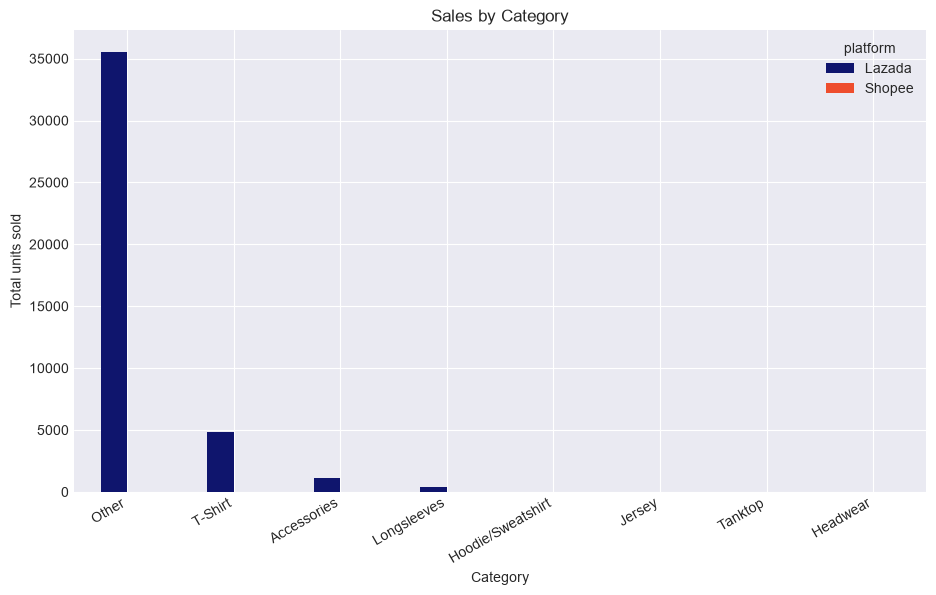

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sales_by_cat = (combined.groupby(["category_derived", "platform"])["sold_final"]
                .sum().unstack(fill_value=0))
sales_by_cat = sales_by_cat.loc[sales_by_cat.sum(axis=1).sort_values(ascending=False).index]
sales_by_cat.plot(kind="bar", ax=ax, color=[PALETTE.get(c, "gray") for c in sales_by_cat.columns])
ax.set_xlabel("Category"); ax.set_ylabel("Total units sold")
ax.set_title("Sales by Category")
plt.xticks(rotation=30, ha="right")
plt.show()

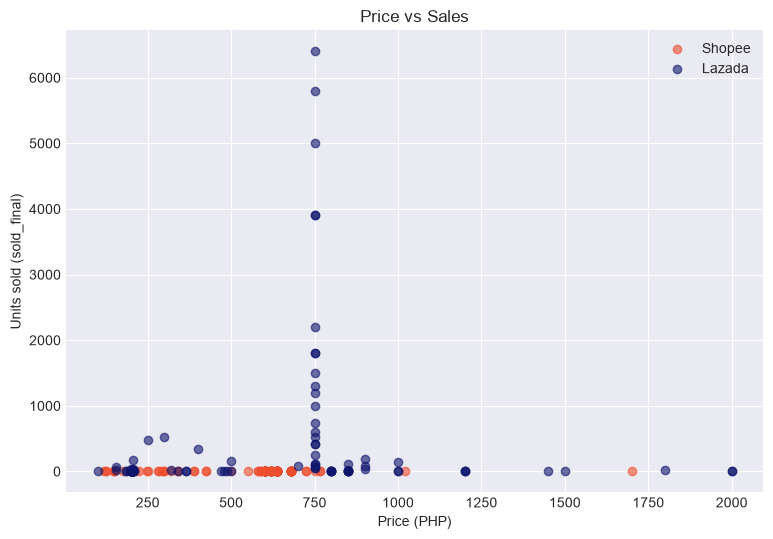

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
for plat in ["Shopee", "Lazada"]:
    d = combined[combined["platform"] == plat]
    ax.scatter(d["price"], d["sold_final"], alpha=0.6, label=plat, color=PALETTE[plat])
ax.set_xlabel("Price (PHP)"); ax.set_ylabel("Units sold (sold_final)")
ax.set_title("Price vs Sales")
ax.legend()
plt.show()

## 5. Ratings & Reviews

In [10]:
rated = combined[combined["has_ratings"]]
avg_rating = rated.groupby("platform")["rating_avg"].mean().round(3)
avg_rating

platform
Lazada    4.395
Shopee    4.881
Name: rating_avg, dtype: float64

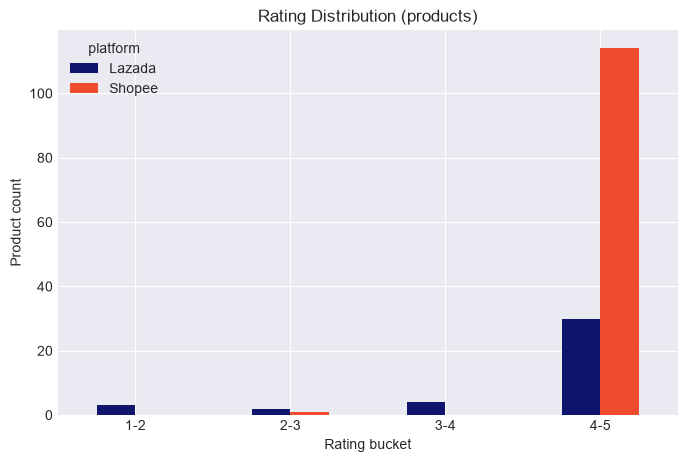

In [11]:
bins, labels = [1, 2, 3, 4, 5], ["1-2", "2-3", "3-4", "4-5"]
rated_copy = rated.copy()
rated_copy["rating_bucket"] = pd.cut(rated_copy["rating_avg"], bins=bins, labels=labels,
                                      include_lowest=True)
bucket_counts = (rated_copy.groupby(["rating_bucket", "platform"], observed=True).size()
                 .unstack(fill_value=0).reindex(labels))

fig, ax = plt.subplots(figsize=(8, 5))
bucket_counts.plot(kind="bar", ax=ax, color=[PALETTE.get(c, "gray") for c in bucket_counts.columns])
ax.set_xlabel("Rating bucket"); ax.set_ylabel("Product count")
ax.set_title("Rating Distribution (products)")
plt.xticks(rotation=0)
plt.show()

In [12]:
top_rated = (combined[combined["review_count"] >= 10]
             .sort_values("rating_avg", ascending=False).head(10)
             [["platform", "product_name_clean", "rating_avg", "review_count"]])
top_rated

,platform,product_name_clean,rating_avg,review_count
154,Lazada,HGHMNDS - PRICE CHECK,5.0,211
156,Lazada,SURFER - HGHMNDS,5.0,1048
82,Shopee,HGHMNDS ONLINE - LIFE RIDER SHIRT,5.0,17
112,Shopee,HGHMNDS ONLINE - SWORD KEY,5.0,15
111,Shopee,HGHMNDS x FLIPTOP - Kinse Shirt,5.0,25
183,Lazada,HGHMNDS - MILLIONS,5.0,370
20,Shopee,HGHMNDS CLO - THUNDERSTRUCK MONO,5.0,33
182,Lazada,HGHMNDS ONLINE - STREET RAISED HOODIE,5.0,10
152,Lazada,HGHMNDS CLO. - Seek Clarity Shirt,5.0,17
205,Lazada,HGHMNDS ONLINE - HEAVY MEDAL SHIRT,5.0,10


In [13]:
for plat in ["Shopee", "Lazada"]:
    d = rated[rated["platform"] == plat]
    r = d["rating_avg"].corr(d["review_count"])
    print(f"{plat}: Pearson r (rating_avg vs review_count) = {r:.4f}")

Shopee: Pearson r (rating_avg vs review_count) = 0.2023
Lazada: Pearson r (rating_avg vs review_count) = 0.1874


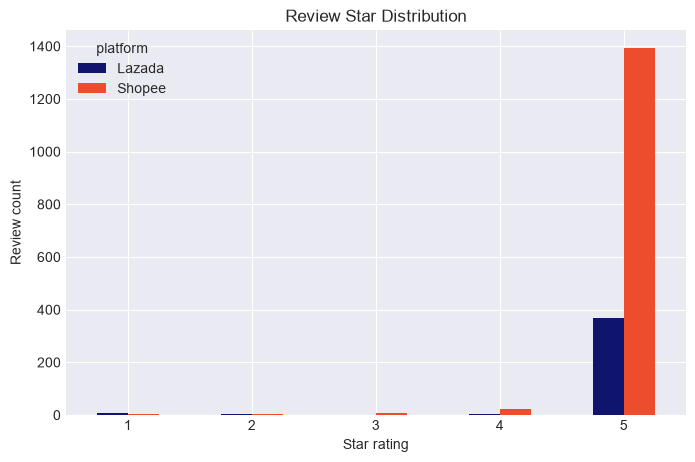

In [14]:
all_reviews = pd.concat([
    shopee_reviews.assign(platform="Shopee"),
    lazada_reviews.assign(platform="Lazada"),
], ignore_index=True)

star_counts = (all_reviews.groupby(["rating", "platform"]).size()
               .unstack(fill_value=0).reindex(range(1, 6), fill_value=0))

fig, ax = plt.subplots(figsize=(8, 5))
star_counts.plot(kind="bar", ax=ax, color=[PALETTE.get(c, "gray") for c in star_counts.columns])
ax.set_xlabel("Star rating"); ax.set_ylabel("Review count")
ax.set_title("Review Star Distribution")
plt.xticks(rotation=0)
plt.show()

In [15]:
def word_freq(texts, top_n=20):
    counter = Counter()
    for t in texts.dropna().astype(str):
        for w in re.findall(r"[a-zA-Z']+", t.lower()):
            if w not in STOPWORDS and len(w) > 1:
                counter[w] += 1
    return counter.most_common(top_n)

five_star = word_freq(all_reviews.loc[all_reviews["rating"] == 5, "review_text"])
one_star = word_freq(all_reviews.loc[all_reviews["rating"] == 1, "review_text"])

pd.DataFrame({
    "5-star word": [w for w, _ in five_star], "5-star count": [c for _, c in five_star],
    "1-star word": [w for w, _ in one_star] + [""] * (20 - len(one_star)),
    "1-star count": [c for _, c in one_star] + [""] * (20 - len(one_star)),
})

,5-star word,5-star count,1-star word,1-star count
0,quality,1090,ng,6
1,material,700,sa,6
2,appearance,695,tapos,4
3,colour,680,na,4
4,good,565,mga,4
5,ng,376,quality,4
6,na,366,po,3
7,solid,336,yung,2
8,sa,289,isa,2
9,ang,281,paano,2


## 6. Platform Comparison

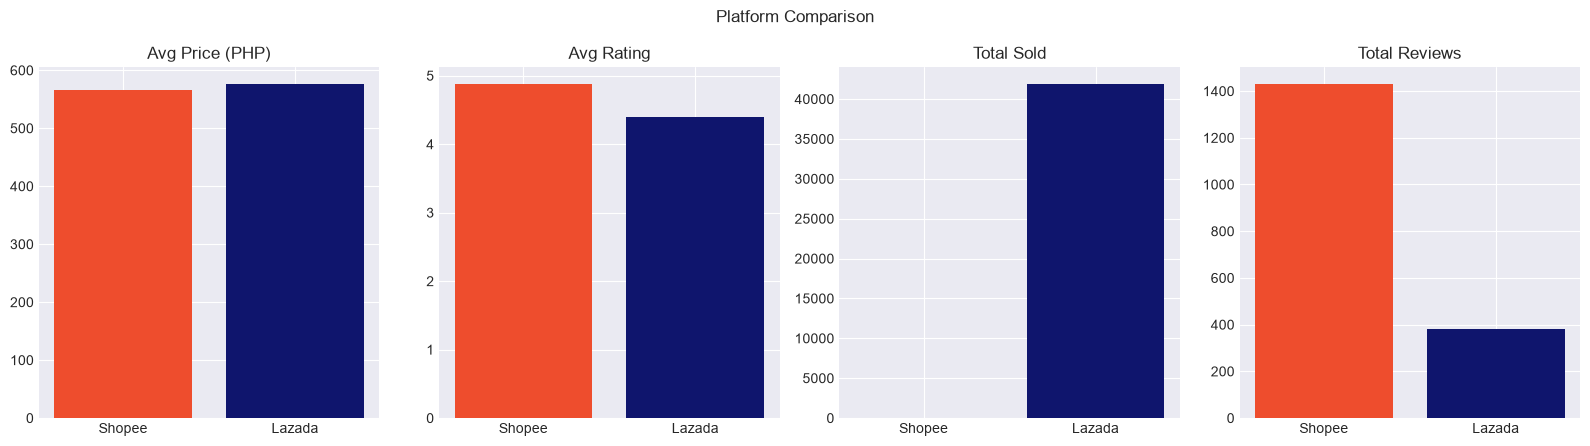

In [16]:
review_counts = {"Shopee": len(shopee_reviews), "Lazada": len(lazada_reviews)}
metrics = {
    "Avg Price (PHP)": price_stats["mean"].to_dict(),
    "Avg Rating": avg_rating.to_dict(),
    "Total Sold": total_sold.to_dict(),
    "Total Reviews": review_counts,
}
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, (metric_name, vals) in zip(axes, metrics.items()):
    plats = ["Shopee", "Lazada"]
    ax.bar(plats, [vals.get(p, 0) for p in plats], color=[PALETTE[p] for p in plats])
    ax.set_title(metric_name)
fig.suptitle("Platform Comparison")
plt.tight_layout()
plt.show()

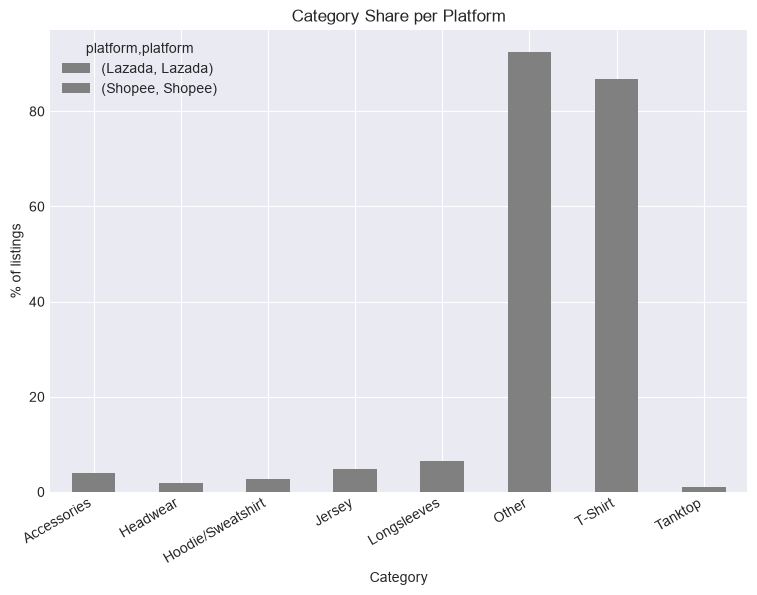

In [17]:
cat_share = (combined.groupby(["platform", "category_derived"]).size()
             .groupby(level=0).apply(lambda s: (s / s.sum() * 100).round(2))
             .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(9, 6))
cat_share.T.plot(kind="bar", stacked=True, ax=ax,
                  color=[PALETTE.get(c, "gray") for c in cat_share.index])
ax.set_xlabel("Category"); ax.set_ylabel("% of listings")
ax.set_title("Category Share per Platform")
plt.xticks(rotation=30, ha="right")
plt.show()

## 7. Suspicious Listings

In [18]:
suspicious = pd.read_csv(CLEANED_DIR / "suspicious_listings.csv")
susp_by_plat = suspicious["platform"].value_counts()
total_by_plat = combined["platform"].value_counts()
susp_pct = (susp_by_plat / total_by_plat * 100).round(2)

print(f"Total suspicious: {len(suspicious)} / {len(combined)} "
      f"({len(suspicious) / len(combined) * 100:.2f}%)")
for plat in ["Shopee", "Lazada"]:
    print(f"  {plat}: {int(susp_by_plat.get(plat, 0))} / {total_by_plat.get(plat, 0)} "
          f"({susp_pct.get(plat, 0)}%)")
print(f"\nAverage discount % among suspicious listings: {suspicious['discount_pct'].mean():.2f}%")

Total suspicious: 54 / 221 (24.43%)
  Shopee: 12 / 118 (10.17%)
  Lazada: 42 / 103 (40.78%)

Average discount % among suspicious listings: 82.55%


In [19]:
top5_suspicious = suspicious.sort_values("discount_pct", ascending=False).head(5)[
    ["platform", "product_name_clean", "price", "original_price", "discount_pct"]]
top5_suspicious

,platform,product_name_clean,price,original_price,discount_pct
41,Lazada,HGHMNDS CLO. - Life Force Shirt,156.0,6969.0,97.8
30,Lazada,HGHMNDS CLO. - REDEMPTION,156.0,6969.0,97.8
50,Lazada,HIGHMINDS CLOTHING V3 INSPIRED OVERSIZED TSHIR...,199.0,7777.0,97.4
31,Lazada,HIGHMINDS CLOTHING V2 INSPIRED OVERSIZED TSHIR...,199.0,7777.0,97.4
24,Lazada,HIGHMINDS CLOTHING V7 INSPIRED OVERSIZED TSHIR...,199.0,7777.0,97.4


## 8. Key Findings

- **Shopee lists at a premium but sells fewer units on record.** Shopee's median
  price (PHP 620) is higher than Lazada's (PHP 500), and Shopee products carry far
  more reviews (1,431 vs 381) and a higher average rating (4.88 vs 4.40) — but
  Shopee's `sold_final` metric is 0 across the board because the item-detail API
  that reports sales counts was blocked during this scrape. Only Lazada's
  lifetime sales figures are usable for volume analysis this run.
- **Lazada carries far more knockoff risk.** ~41% of Lazada listings are flagged
  `is_suspicious` (discount > 80% or price under ₱250, usually both — fake
  "original prices" like ₱7,777 discounted to ₱199), versus ~10% on Shopee.
- **"Other" is the largest category on both platforms** because many product
  names (e.g. "AURORA - HGHMNDS", "HGHMNDS - DIAGRAM") don't contain an explicit
  garment-type keyword (shirt/tee/hoodie/etc.) — the category rules only match
  on literal keywords, so abstractly-named products fall through. This is a
  known limitation of the simple keyword-based classifier used in this pipeline.
- **`is_authentic` is true for virtually all 221 listings** since it only checks
  whether the product name mentions HGHMNDS/HIGHMINDS/HIGH MINDS — it does not
  by itself distinguish the official store from resellers or knockoffs (that's
  what `is_suspicious` is for).
- **Ratings barely correlate with review volume** (Pearson r ~0.19–0.20 on both
  platforms) — popular items aren't systematically rated higher or lower than
  niche ones.
- **Reviews mix English and Filipino.** The 1-star word-frequency table is
  dominated by Filipino function words (ng, sa, na, mga) because the stopword
  list used is English-only — a sign that negative reviews skew more
  Filipino-language than 5-star reviews, and that word-frequency analysis would
  benefit from a bilingual stopword list in a future iteration.

## 9. Next Steps

- **Dashboard deployment**: `scripts/03_export_json.py` produces
  `assets/data/*.json` for a front-end dashboard; `.github/workflows/deploy.yml`
  publishes `assets/` to GitHub Pages on every push to `main`.
- **Future scrape schedule**: re-run the scraper periodically (e.g. weekly) to
  refresh `data/raw/`, then re-run `scripts/01_clean.py` -> `02_eda.py` ->
  `03_export_json.py` (or let CI do it) so the dashboard reflects current
  prices, stock, and new listings rather than this snapshot.
- Revisit the category classifier to reduce the "Other" bucket, and consider a
  bilingual stopword list for review text analysis.